# Missing Data Analysis - V4 Datasets (2023-2025)

Comprehensive missing data analysis across OpenAQ, OpenMeteo, and JARTIC datasets for feature selection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## Load Datasets

In [2]:
openaq = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openaq_processed_20230601_to_20250630.csv')
openaq['timestamp'] = pd.to_datetime(openaq['timestamp'])

openmeteo = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openmeteo_processed_20230601_to_20250630.csv')
openmeteo['timestamp'] = pd.to_datetime(openmeteo['timestamp'], format='mixed')

jartic = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_jartic_processed_20230601_to_20250630_full.csv')
jartic['timestamp'] = pd.to_datetime(jartic['timestamp'])

print(f"OpenAQ: {openaq.shape[0]:,} rows × {openaq.shape[1]} columns")
print(f"OpenMeteo: {openmeteo.shape[0]:,} rows × {openmeteo.shape[1]} columns")
print(f"JARTIC: {jartic.shape[0]:,} rows × {jartic.shape[1]} columns")

OpenAQ: 9,579,181 rows × 26 columns
OpenMeteo: 547,920 rows × 41 columns
JARTIC: 18,849,324 rows × 15 columns


## Missing Data Summary

In [3]:
def get_missing_summary(df, name):
    feature_cols = [col for col in df.columns if 'mean' in col or 'volume' in col]
    missing_pct = (df[feature_cols].isnull().sum() / len(df) * 100).round(2)
    available_pct = 100 - missing_pct
    
    summary = pd.DataFrame({
        'Dataset': name,
        'Feature': missing_pct.index,
        'Missing_Pct': missing_pct.values,
        'Available_Pct': available_pct.values
    })
    return summary.sort_values('Available_Pct', ascending=False)

openaq_summary = get_missing_summary(openaq, 'OpenAQ')
openmeteo_summary = get_missing_summary(openmeteo, 'OpenMeteo')
jartic_summary = get_missing_summary(jartic, 'JARTIC')

all_summaries = pd.concat([openaq_summary, openmeteo_summary, jartic_summary])
display(all_summaries.pivot_table(index='Feature', columns='Dataset', values='Available_Pct', fill_value=0))

Dataset,JARTIC,OpenAQ,OpenMeteo
Feature,,,
avg_traffic_volume,100.00,0.00,0.00
cloud_cover_pct_mean,0.00,0.00,100.00
co_ppm_mean,0.00,20.57,0.00
dew_point_c_mean,0.00,0.00,100.00
humidity_pct_mean,0.00,0.00,100.00
max_traffic_volume,100.00,0.00,0.00
no2_ugm3_mean,0.00,96.82,0.00
pm25_ugm3_mean,0.00,79.98,0.00
precipitation_mm_mean,0.00,0.00,100.00


## Temporal Coverage Comparison

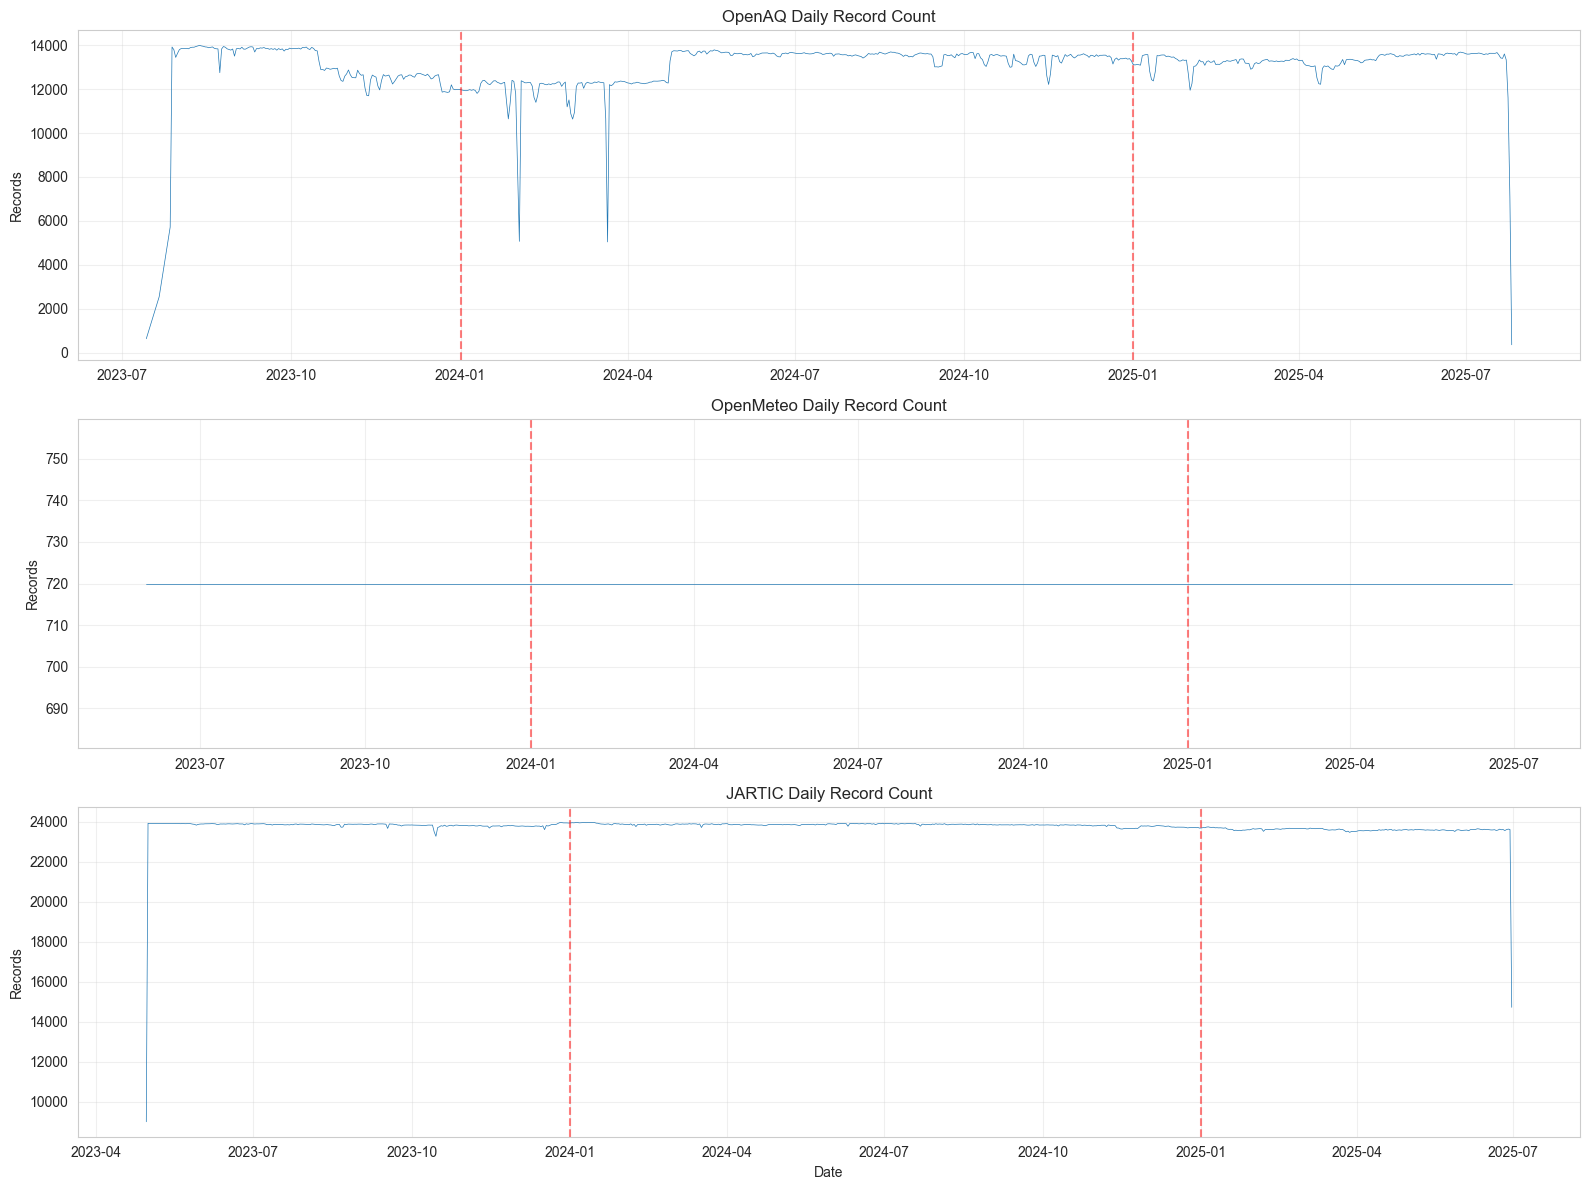

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

datasets = [('OpenAQ', openaq), ('OpenMeteo', openmeteo), ('JARTIC', jartic)]

for idx, (name, df) in enumerate(datasets):
    daily_counts = df.groupby(df['timestamp'].dt.date).size()
    axes[idx].plot(daily_counts.index, daily_counts.values, linewidth=0.5)
    axes[idx].set_title(f'{name} Daily Record Count', fontsize=12)
    axes[idx].set_ylabel('Records')
    axes[idx].grid(True, alpha=0.3)
    
    for year in [2024, 2025]:
        axes[idx].axvline(x=pd.Timestamp(f'{year}-01-01').date(), color='red', linestyle='--', alpha=0.5)

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.show()

## Missing Data Heatmaps

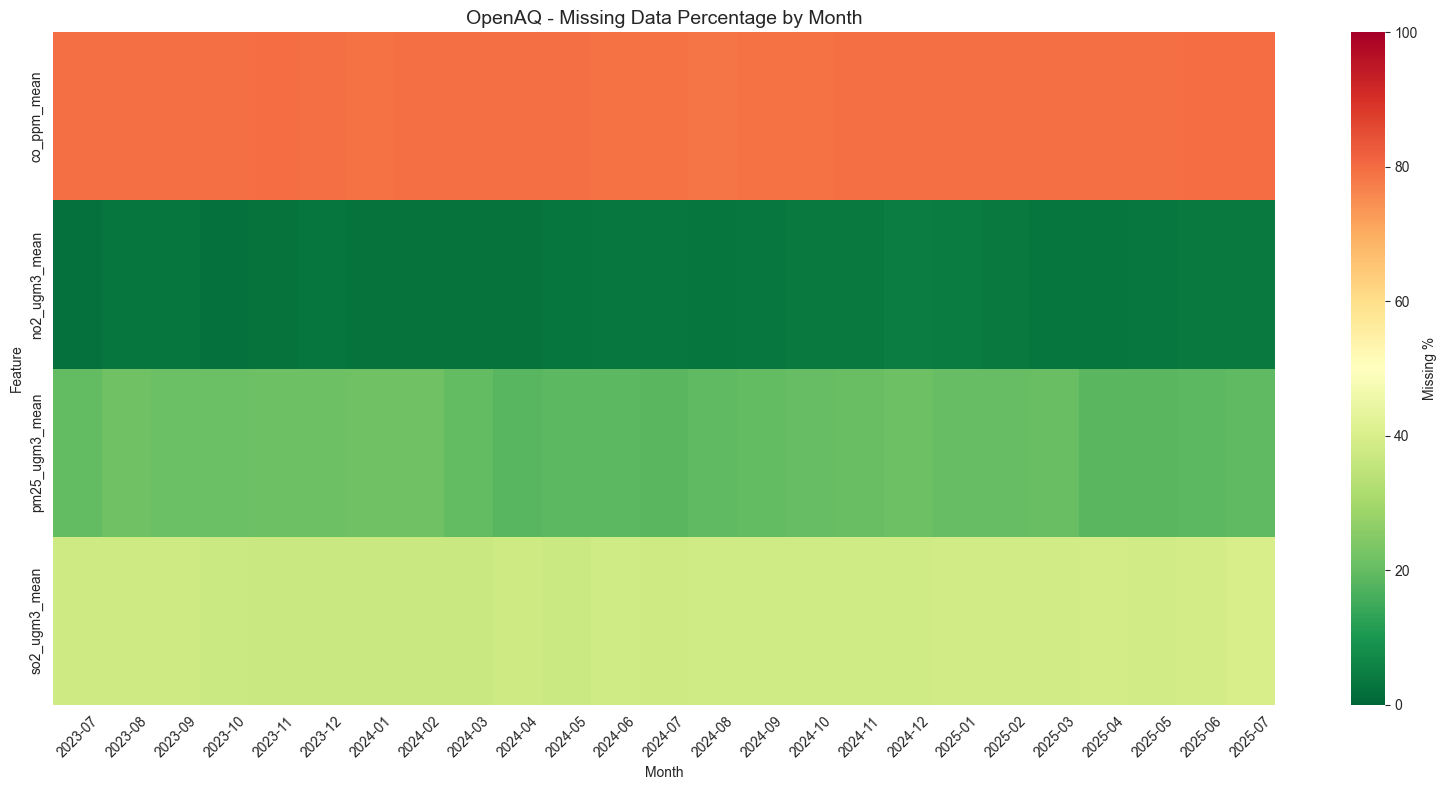

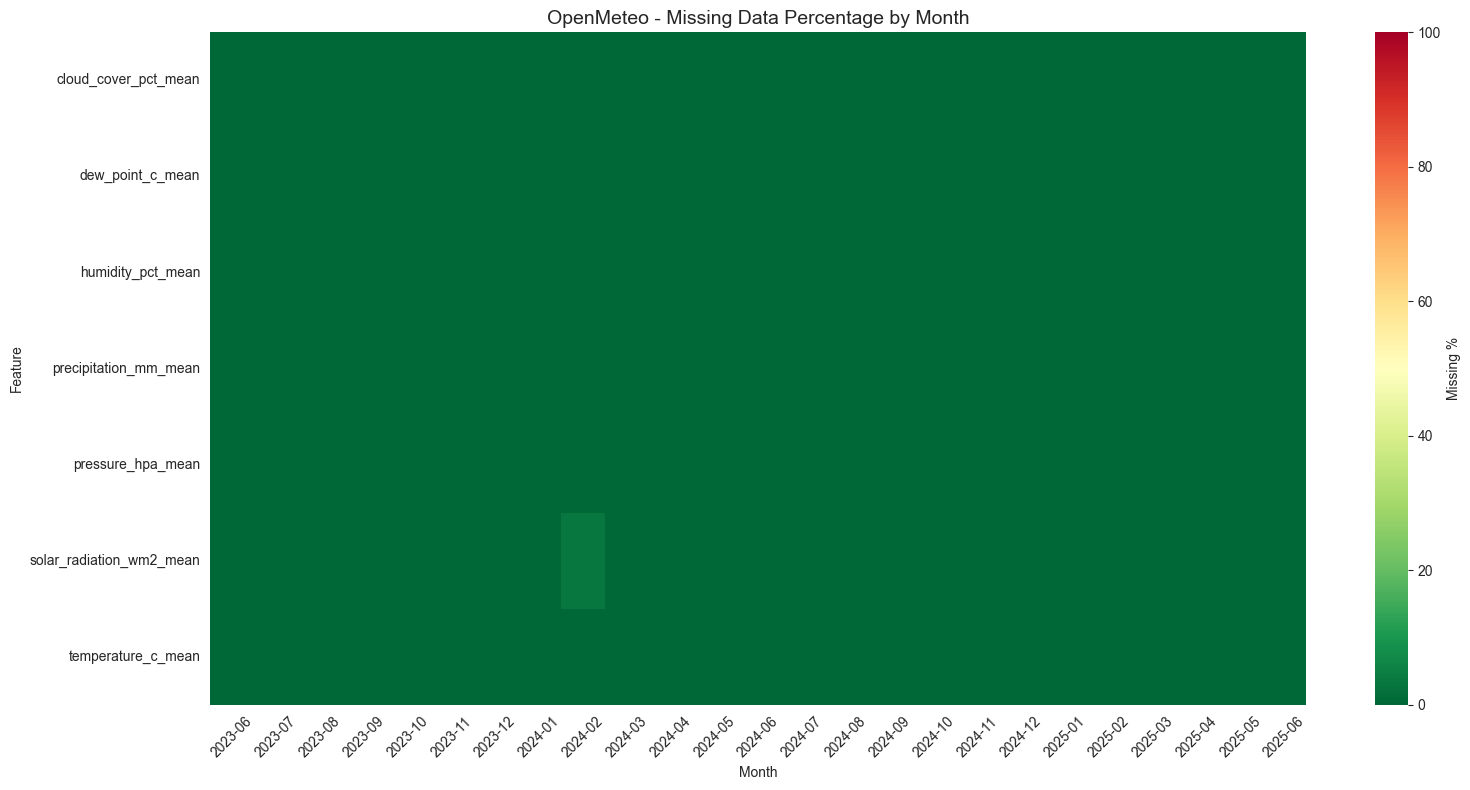

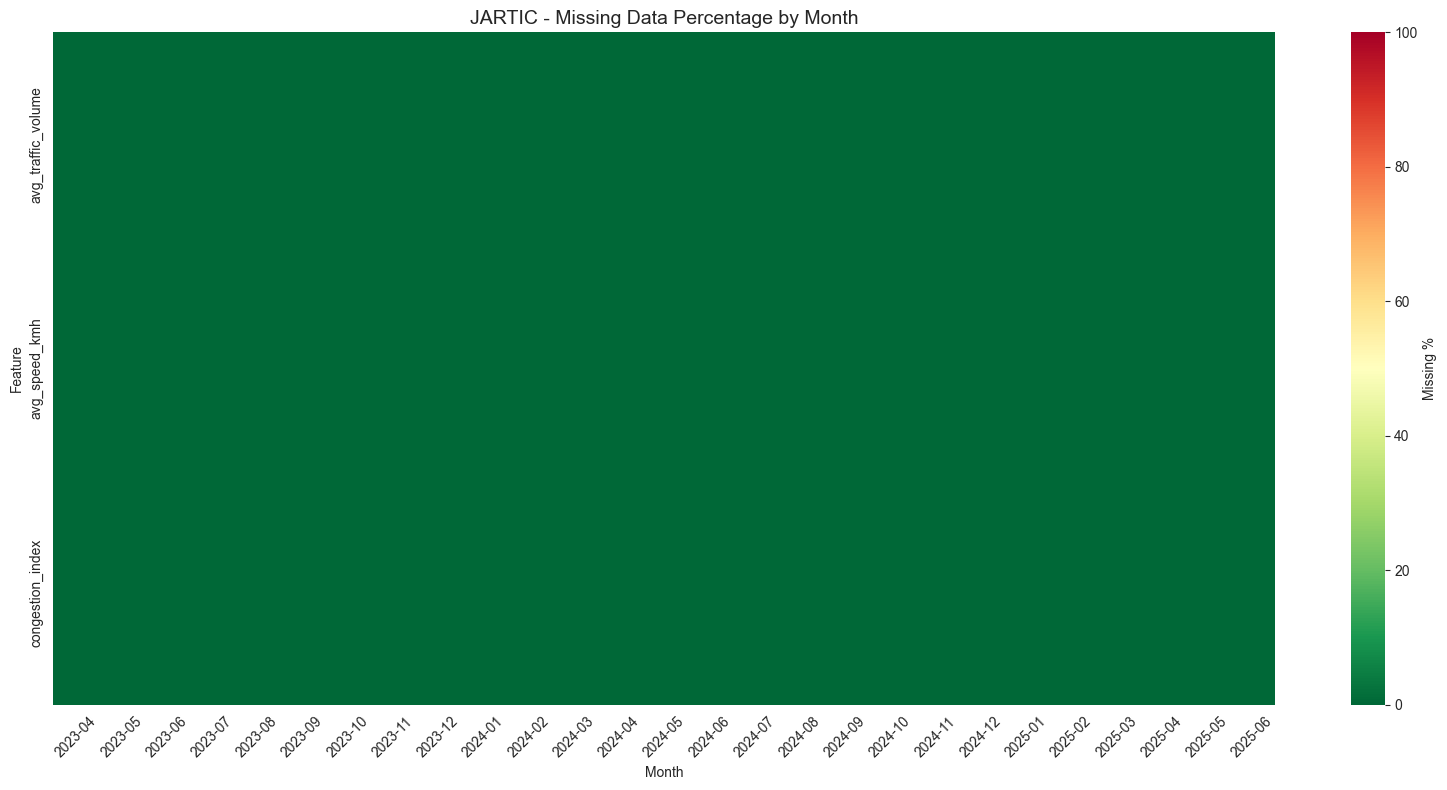

In [5]:
def create_missing_heatmap(df, name, feature_cols):
    df['year_month'] = df['timestamp'].dt.to_period('M')
    
    missing_matrix = df.groupby('year_month')[feature_cols].apply(
        lambda x: x.isnull().mean() * 100
    ).T
    
    plt.figure(figsize=(16, 8))
    sns.heatmap(missing_matrix, cmap='RdYlGn_r', vmin=0, vmax=100, 
                annot=False, fmt='.0f', cbar_kws={'label': 'Missing %'})
    plt.title(f'{name} - Missing Data Percentage by Month', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel('Feature')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return missing_matrix

openaq_features = [col for col in openaq.columns if 'mean' in col]
openaq_missing = create_missing_heatmap(openaq, 'OpenAQ', openaq_features)

openmeteo_features = [col for col in openmeteo.columns if 'mean' in col]
openmeteo_missing = create_missing_heatmap(openmeteo, 'OpenMeteo', openmeteo_features)

jartic_features = ['avg_traffic_volume', 'avg_speed_kmh', 'congestion_index']
jartic_missing = create_missing_heatmap(jartic, 'JARTIC', jartic_features)

## Spatial Coverage Analysis

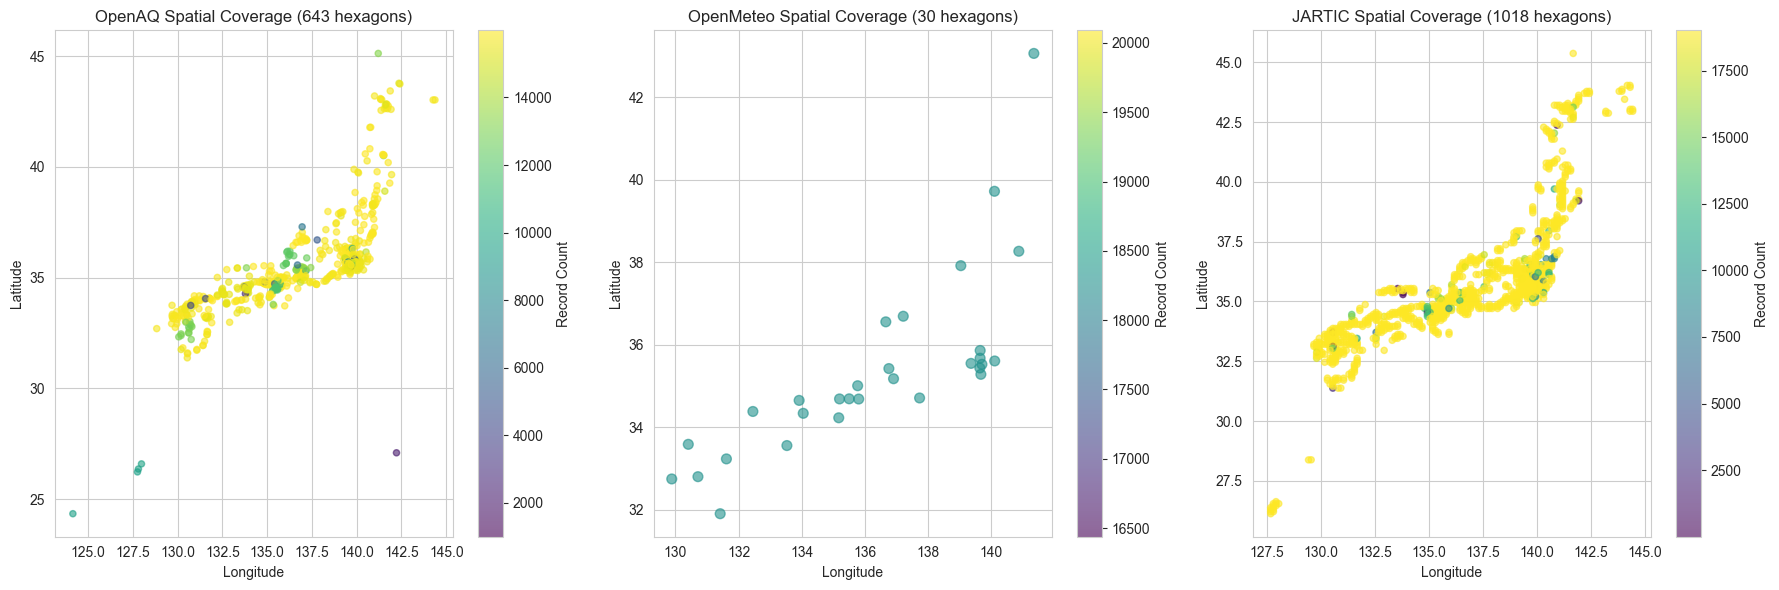

Spatial Coverage Summary:
OpenAQ: 643 hexagons
OpenMeteo: 30 hexagons
JARTIC: 1018 hexagons


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

openaq_hex = openaq.groupby(['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8']).size().reset_index(name='count')
scatter1 = axes[0].scatter(openaq_hex['h3_lon_res8'], openaq_hex['h3_lat_res8'], 
                          c=openaq_hex['count'], cmap='viridis', s=20, alpha=0.6)
axes[0].set_title(f'OpenAQ Spatial Coverage ({len(openaq_hex)} hexagons)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(scatter1, ax=axes[0], label='Record Count')

openmeteo_hex = openmeteo.groupby(['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8']).size().reset_index(name='count')
scatter2 = axes[1].scatter(openmeteo_hex['h3_lon_res8'], openmeteo_hex['h3_lat_res8'], 
                          c=openmeteo_hex['count'], cmap='viridis', s=50, alpha=0.6)
axes[1].set_title(f'OpenMeteo Spatial Coverage ({len(openmeteo_hex)} hexagons)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(scatter2, ax=axes[1], label='Record Count')

jartic_hex = jartic.groupby(['h3_index_res8', 'h3_lat_res8', 'h3_lon_res8']).size().reset_index(name='count')
scatter3 = axes[2].scatter(jartic_hex['h3_lon_res8'], jartic_hex['h3_lat_res8'], 
                          c=jartic_hex['count'], cmap='viridis', s=20, alpha=0.6)
axes[2].set_title(f'JARTIC Spatial Coverage ({len(jartic_hex)} hexagons)')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
plt.colorbar(scatter3, ax=axes[2], label='Record Count')

plt.tight_layout()
plt.show()

print(f"Spatial Coverage Summary:")
print(f"OpenAQ: {len(openaq_hex)} hexagons")
print(f"OpenMeteo: {len(openmeteo_hex)} hexagons")
print(f"JARTIC: {len(jartic_hex)} hexagons")

## Feature Completeness Ranking

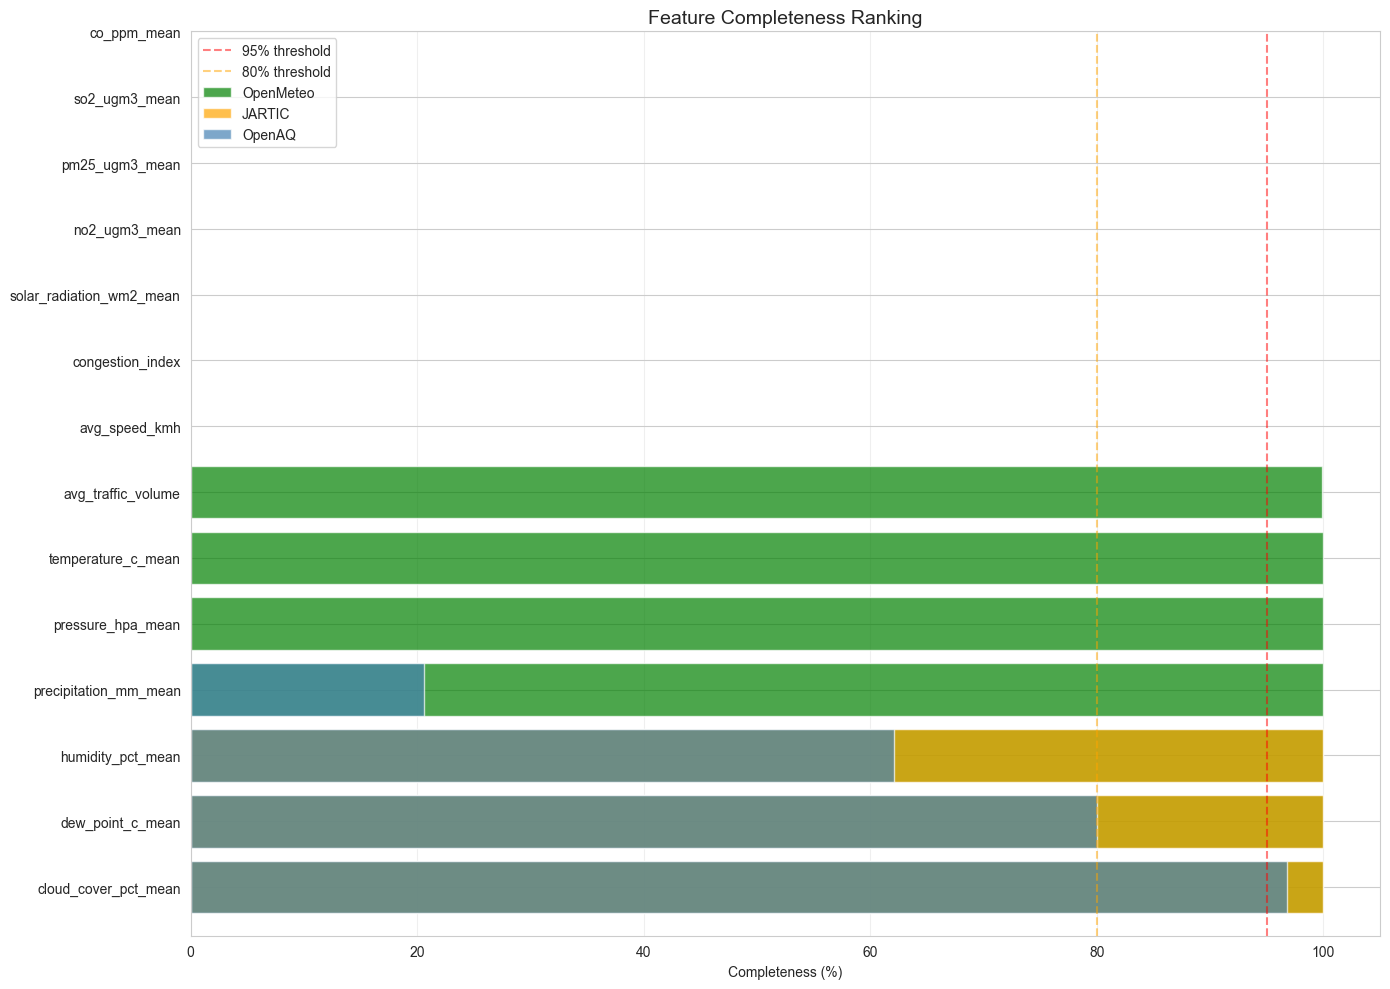

,Dataset,Feature,Completeness,Records
4,OpenMeteo,cloud_cover_pct_mean,100.00,547920
5,OpenMeteo,dew_point_c_mean,100.00,547920
6,OpenMeteo,humidity_pct_mean,100.00,547920
7,OpenMeteo,precipitation_mm_mean,100.00,547920
8,OpenMeteo,pressure_hpa_mean,100.00,547920
10,OpenMeteo,temperature_c_mean,100.00,547920
11,JARTIC,avg_traffic_volume,100.00,18849324
12,JARTIC,avg_speed_kmh,100.00,18849324
13,JARTIC,congestion_index,100.00,18849324
9,OpenMeteo,solar_radiation_wm2_mean,99.87,547224


In [7]:
feature_completeness = []

for col in openaq_features:
    completeness = (openaq[col].notna().sum() / len(openaq)) * 100
    feature_completeness.append({
        'Dataset': 'OpenAQ',
        'Feature': col,
        'Completeness': completeness,
        'Records': openaq[col].notna().sum()
    })

for col in openmeteo_features:
    completeness = (openmeteo[col].notna().sum() / len(openmeteo)) * 100
    feature_completeness.append({
        'Dataset': 'OpenMeteo',
        'Feature': col,
        'Completeness': completeness,
        'Records': openmeteo[col].notna().sum()
    })

for col in jartic_features:
    completeness = (jartic[col].notna().sum() / len(jartic)) * 100
    feature_completeness.append({
        'Dataset': 'JARTIC',
        'Feature': col,
        'Completeness': completeness,
        'Records': jartic[col].notna().sum()
    })

completeness_df = pd.DataFrame(feature_completeness).sort_values('Completeness', ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
colors = {'OpenAQ': 'steelblue', 'OpenMeteo': 'green', 'JARTIC': 'orange'}
for dataset in completeness_df['Dataset'].unique():
    data = completeness_df[completeness_df['Dataset'] == dataset]
    ax.barh(range(len(data)), data['Completeness'].values, 
            label=dataset, color=colors[dataset], alpha=0.7)

ax.set_yticks(range(len(completeness_df)))
ax.set_yticklabels(completeness_df['Feature'].values)
ax.set_xlabel('Completeness (%)')
ax.set_title('Feature Completeness Ranking', fontsize=14)
ax.axvline(x=95, color='red', linestyle='--', alpha=0.5, label='95% threshold')
ax.axvline(x=80, color='orange', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

display(completeness_df)

## Recommended Feature Set

In [8]:
core_features = completeness_df[completeness_df['Completeness'] >= 95]
supplementary_features = completeness_df[(completeness_df['Completeness'] >= 70) & (completeness_df['Completeness'] < 95)]
exclude_features = completeness_df[completeness_df['Completeness'] < 70]

print("CORE FEATURES (≥95% complete):")
print("="*60)
for _, row in core_features.iterrows():
    print(f"{row['Dataset']:10s} | {row['Feature']:30s} | {row['Completeness']:.1f}%")

print("\nSUPPLEMENTARY FEATURES (70-95% complete):")
print("="*60)
for _, row in supplementary_features.iterrows():
    print(f"{row['Dataset']:10s} | {row['Feature']:30s} | {row['Completeness']:.1f}%")

print("\nEXCLUDE FEATURES (<70% complete):")
print("="*60)
for _, row in exclude_features.iterrows():
    print(f"{row['Dataset']:10s} | {row['Feature']:30s} | {row['Completeness']:.1f}%")

CORE FEATURES (≥95% complete):
OpenMeteo  | cloud_cover_pct_mean           | 100.0%
OpenMeteo  | dew_point_c_mean               | 100.0%
OpenMeteo  | humidity_pct_mean              | 100.0%
OpenMeteo  | precipitation_mm_mean          | 100.0%
OpenMeteo  | pressure_hpa_mean              | 100.0%
OpenMeteo  | temperature_c_mean             | 100.0%
JARTIC     | avg_traffic_volume             | 100.0%
JARTIC     | avg_speed_kmh                  | 100.0%
JARTIC     | congestion_index               | 100.0%
OpenMeteo  | solar_radiation_wm2_mean       | 99.9%
OpenAQ     | no2_ugm3_mean                  | 96.8%

SUPPLEMENTARY FEATURES (70-95% complete):
OpenAQ     | pm25_ugm3_mean                 | 80.0%

EXCLUDE FEATURES (<70% complete):
OpenAQ     | so2_ugm3_mean                  | 62.1%
OpenAQ     | co_ppm_mean                    | 20.6%


## Cross-Dataset Temporal Alignment

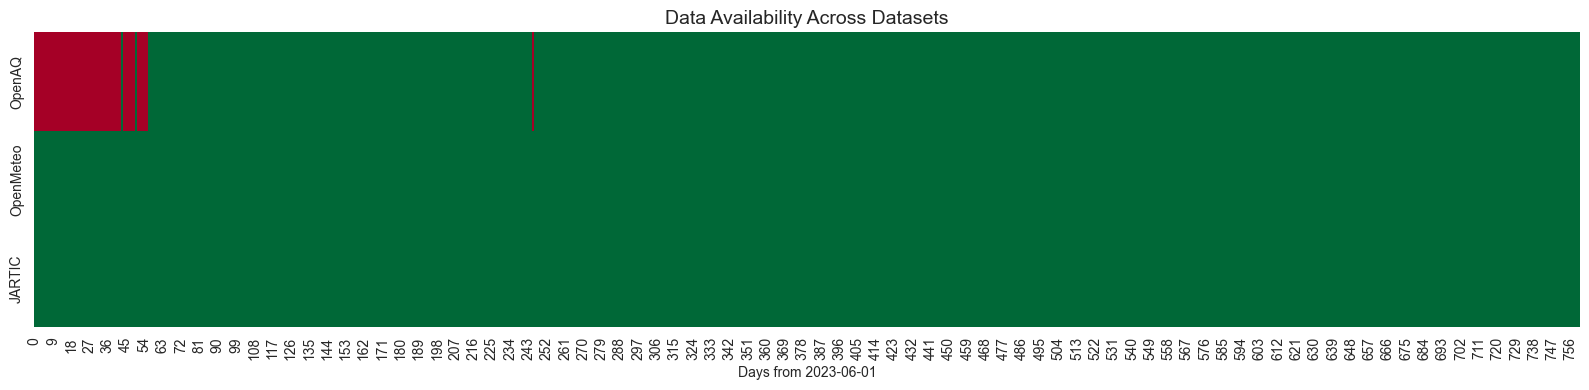

Days with all datasets available: 706 / 761 (92.8%)
OpenAQ coverage: 92.8%
OpenMeteo coverage: 100.0%
JARTIC coverage: 100.0%


: 

In [ ]:
date_range = pd.date_range('2023-06-01', '2025-06-30', freq='D')

openaq_dates = set(openaq['timestamp'].dt.date)
openmeteo_dates = set(openmeteo['timestamp'].dt.date)
jartic_dates = set(jartic['timestamp'].dt.date)

alignment_matrix = pd.DataFrame({
    'Date': date_range,
    'OpenAQ': [1 if d.date() in openaq_dates else 0 for d in date_range],
    'OpenMeteo': [1 if d.date() in openmeteo_dates else 0 for d in date_range],
    'JARTIC': [1 if d.date() in jartic_dates else 0 for d in date_range]
})

alignment_matrix['All_Available'] = (alignment_matrix[['OpenAQ', 'OpenMeteo', 'JARTIC']].sum(axis=1) == 3).astype(int)

fig, ax = plt.subplots(figsize=(16, 4))
data_to_plot = alignment_matrix[['OpenAQ', 'OpenMeteo', 'JARTIC']].T
sns.heatmap(data_to_plot, cmap='RdYlGn', cbar=False, ax=ax, yticklabels=['OpenAQ', 'OpenMeteo', 'JARTIC'])
ax.set_xlabel('Days from 2023-06-01')
ax.set_title('Data Availability Across Datasets', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Days with all datasets available: {alignment_matrix['All_Available'].sum()} / {len(alignment_matrix)} ({alignment_matrix['All_Available'].mean()*100:.1f}%)")
print(f"OpenAQ coverage: {alignment_matrix['OpenAQ'].mean()*100:.1f}%")
print(f"OpenMeteo coverage: {alignment_matrix['OpenMeteo'].mean()*100:.1f}%")
print(f"JARTIC coverage: {alignment_matrix['JARTIC'].mean()*100:.1f}%")